# WID3002 Group Assignment G28
# Personalized News Recommendation System

---
## Data Preprocessing

In [4]:
import pandas as pd
import os

BASE_DIR  = r"C:\Users\Administrator\OneDrive\Desktop\WID3002 MINDsmall Dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "MINDsmall_train")
DEV_DIR   = os.path.join(BASE_DIR, "MINDsmall_dev")

# Column names based on MIND dataset documentation
NEWS_COLS     = ["news_id", "category", "subcategory", "title", "abstract",
                 "url", "title_entities", "abstract_entities"]
BEHAVIOR_COLS = ["impression_id", "user_id", "timestamp", "history", "impressions"]

In [5]:
def load_news(folder):
    return pd.read_csv(os.path.join(folder, "news.tsv"), sep="\t", header=None, names=NEWS_COLS)

# Combine train and dev news, drop duplicates since some articles appear in both
news_raw = pd.concat([load_news(TRAIN_DIR), load_news(DEV_DIR)]).drop_duplicates(subset="news_id")

articles = news_raw[["news_id", "category", "title", "abstract"]].copy()
articles.dropna(subset=["title", "abstract"], inplace=True)
articles = articles[articles["title"].str.strip() != ""]
articles = articles[articles["abstract"].str.strip() != ""]
articles["category"] = articles["category"].str.strip().str.lower()
articles.reset_index(drop=True, inplace=True)
print(f"Articles after cleaning: {len(articles)}")
articles.head()

Articles after cleaning: 61823


,news_id,category,title,abstract
0,N55528,lifestyle,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the..."
1,N19639,health,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...
2,N61837,news,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...
3,N53526,health,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi..."
4,N38324,health,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re..."


In [6]:
def load_behaviors(folder, split):
    df = pd.read_csv(os.path.join(folder, "behaviors.tsv"), sep="\t", header=None, names=BEHAVIOR_COLS)
    df["split"] = split
    return df

behaviors = pd.concat([load_behaviors(TRAIN_DIR, "train"), load_behaviors(DEV_DIR, "dev")], ignore_index=True)

# Each impression is stored as "NewsID-clicked" pairs in a single string, so we explode them into rows
rows = []
for _, row in behaviors.iterrows():
    if pd.isna(row["impressions"]):
        continue
    for item in row["impressions"].split():
        parts = item.split("-")
        if len(parts) != 2:
            continue
        news_id, clicked = parts
        rows.append({"user_id": row["user_id"], "news_id": news_id,
                     "clicked": int(clicked), "timestamp": row["timestamp"], "split": row["split"]})

interactions = pd.DataFrame(rows)
print(f"Total interaction records: {len(interactions)}")
interactions.head()

Total interaction records: 8584442


,user_id,news_id,clicked,timestamp,split
0,U13740,N55689,1,11/11/2019 9:05:58 AM,train
1,U13740,N35729,0,11/11/2019 9:05:58 AM,train
2,U91836,N20678,0,11/12/2019 6:11:30 PM,train
3,U91836,N39317,0,11/12/2019 6:11:30 PM,train
4,U91836,N58114,0,11/12/2019 6:11:30 PM,train


In [7]:
articles.to_csv(os.path.join(BASE_DIR, "articles.csv"), index=False)
interactions.to_csv(os.path.join(BASE_DIR, "interactions.csv"), index=False)

print("========== DATA QUALITY REPORT ==========")
print(f"Articles:        {len(articles)} | Null titles: {articles['title'].isna().sum()} | Null abstracts: {articles['abstract'].isna().sum()}")
print(f"Interactions:    {len(interactions)} | Clicked: {interactions['clicked'].sum()} | Users: {interactions['user_id'].nunique()}")
print("\nCategory distribution:")
print(articles["category"].value_counts().to_string())

========== DATA QUALITY REPORT ==========
Articles:        61823 | Null titles: 0 | Null abstracts: 0
Interactions:    8584442 | Clicked: 347727 | Users: 94057

Category distribution:
category
news             19305
sports           17750
finance           3718
foodanddrink      3072
travel            2843
lifestyle         2795
video             2709
weather           2379
health            2136
autos             1887
tv                1004
music              873
movies             668
entertainment      659
kids                21
middleeast           2
northamerica         1
games                1


---
## NLP Pipeline

In [8]:
import numpy as np
import json
import pickle
import re
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer

# Disable parser and NER since we only need tokenization and lemmatization
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
def clean_text(text):
    text = re.sub(r"<[^>]+>", " ", str(text))  # strip any HTML tags
    text = re.sub(r"\s+", " ", text)
    return text.strip().lower()

def tokenize(text):
    doc = nlp(text)
    # Keep only meaningful words — skip stopwords, punctuation, and single characters
    return " ".join([t.lemma_ for t in doc if not t.is_stop and not t.is_punct and len(t.text) > 1])

print("Cleaning and tokenizing ...")
articles["text"] = articles["title"] + " " + articles["abstract"]
articles["text_clean"]  = articles["text"].apply(clean_text)
articles["text_tokens"] = articles["text_clean"].apply(tokenize)
print("Done.")

Cleaning and tokenizing ...
Done.


In [10]:
# Bigrams (ngram_range=(1,2)) help capture phrases like "breaking news" or "stock market"
tfidf_vectorizer = TfidfVectorizer(max_features=30000, ngram_range=(1, 2))
tfidf_matrix = tfidf_vectorizer.fit_transform(articles["text_tokens"])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

TF-IDF matrix shape: (61823, 30000)


In [11]:
# MiniLM produces 384-dim sentence embeddings and is fast enough to run locally
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
article_embeddings = embedder.encode(
    articles["text_clean"].tolist(), batch_size=64,
    show_progress_bar=True, convert_to_numpy=True
)
print(f"Embeddings shape: {article_embeddings.shape}")

Batches: 100%|██████████| 966/966 [04:31<00:00,  3.56it/s]


Embeddings shape: (61823, 384)


In [12]:
# Map news_id to its row index in article_embeddings for fast lookup
article_id_index = {row["news_id"]: i for i, row in articles.iterrows()}

with open(BASE_DIR + r"\tfidf_vectorizer.pkl", "wb") as f: pickle.dump(tfidf_vectorizer, f)
with open(BASE_DIR + r"\tfidf_matrix.pkl", "wb") as f:    pickle.dump(tfidf_matrix, f)
np.save(BASE_DIR + r"\article_embeddings.npy", article_embeddings)
with open(BASE_DIR + r"\article_id_index.json", "w") as f: json.dump(article_id_index, f)

In [13]:
# Reusable function for encoding new articles at inference time (used by Person 3 & 4)
def encode_article(text):
    cleaned   = clean_text(text)
    tokenized = tokenize(cleaned)
    tfidf_vec = tfidf_vectorizer.transform([tokenized])
    embedding = embedder.encode([cleaned], convert_to_numpy=True)[0]
    return tfidf_vec, embedding

test_tfidf, test_emb = encode_article("Apple releases new iPhone with AI features.")
print(f"TF-IDF shape: {test_tfidf.shape} | Embedding shape: {test_emb.shape}")

TF-IDF shape: (1, 30000) | Embedding shape: (384,)


---
## User Profiling

In [14]:
# Only use train split — dev is reserved for evaluation
clicks = interactions[(interactions["clicked"] == 1) & (interactions["split"] == "train")].copy()
clicks["timestamp"] = pd.to_datetime(clicks["timestamp"])
clicks = clicks.sort_values(["user_id", "timestamp"])
print(f"Train clicks: {len(clicks)} | Unique users: {clicks['user_id'].nunique()}")

Train clicks: 236344 | Unique users: 50000


In [15]:
user_profiles = {}

for user_id, group in clicks.groupby("user_id"):
    valid = group[group["news_id"].isin(article_id_index)]
    if len(valid) == 0:
        continue
    indices = [article_id_index[nid] for nid in valid["news_id"]]
    embs    = article_embeddings[indices]
    n       = len(embs)
    # Give more weight to recently read articles (linear recency weighting)
    weights = np.arange(1, n + 1, dtype=np.float32)
    weights /= weights.sum()
    user_profiles[user_id] = np.average(embs, axis=0, weights=weights)

print(f"User profiles built: {len(user_profiles)}")

User profiles built: 49445


In [16]:
click_counts = clicks.groupby("news_id").size().reset_index(name="click_count")
click_counts = click_counts.merge(articles[["news_id", "category"]], on="news_id", how="left")
click_counts.dropna(subset=["category"], inplace=True)

# Top-20 per category serves as fallback for cold-start users
popular_by_category = {}
for cat, group in click_counts.groupby("category"):
    popular_by_category[cat] = group.nlargest(20, "click_count")["news_id"].tolist()

click_count_per_user = clicks.groupby("user_id").size()
cold_start_users = set(click_count_per_user[click_count_per_user < 3].index)
print(f"Cold-start users: {len(cold_start_users)} | Warm users: {len(user_profiles) - len(cold_start_users & set(user_profiles))}")

Cold-start users: 22322 | Warm users: 27678


In [17]:
with open(BASE_DIR + r"\user_profiles.pkl", "wb") as f: pickle.dump(user_profiles, f)
with open(BASE_DIR + r"\popular_by_category.json", "w") as f: json.dump(popular_by_category, f)

def get_user_profile(user_id):
    return user_profiles.get(user_id, None)

sample = list(user_profiles.keys())[0]
print(f"get_user_profile({sample}): shape={get_user_profile(sample).shape}")

get_user_profile(U100): shape=(384,)


---
## Recommendation Engine

In [18]:
from scipy.sparse import csr_matrix

train_interactions = interactions[interactions["split"] == "train"].copy()

user_list    = sorted(train_interactions["user_id"].unique())
article_list = sorted(train_interactions["news_id"].unique())
user_idx     = {u: i for i, u in enumerate(user_list)}
article_idx  = {a: i for i, a in enumerate(article_list)}

rows_idx = train_interactions["user_id"].map(user_idx)
cols_idx = train_interactions["news_id"].map(article_idx)
vals     = train_interactions["clicked"].values.astype(np.float32)

# Sparse matrix keeps memory usage manageable for 50k users x 20k articles
interaction_matrix = csr_matrix(
    (vals, (rows_idx, cols_idx)),
    shape=(len(user_list), len(article_list))
)
print(f"Interaction matrix: {interaction_matrix.shape}")

Interaction matrix: (50000, 20288)


In [19]:
ALPHA = 0.6  # content-based weight; 1-ALPHA goes to collaborative filtering
TOP_K = 10

def content_score(user_vector, article_embs):
    norm_user = user_vector / (np.linalg.norm(user_vector) + 1e-9)
    norms     = np.linalg.norm(article_embs, axis=1, keepdims=True) + 1e-9
    return article_embs.dot(norm_user) / norms.squeeze()

def collab_score(user_id, top_n_similar=50):
    if user_id not in user_idx:
        return None
    uid   = user_idx[user_id]
    u_vec = interaction_matrix[uid]
    sims  = interaction_matrix.dot(u_vec.T).toarray().flatten()
    sims[uid] = -1  # exclude the user themselves
    top_users  = np.argsort(sims)[::-1][:top_n_similar]
    weights    = sims[top_users]
    weight_sum = weights.sum()
    if weight_sum == 0:
        return None
    return interaction_matrix[top_users].T.dot(weights) / weight_sum

In [20]:
def recommend(user_id, top_k=TOP_K, alpha=ALPHA):
    profile = get_user_profile(user_id)

    # Fall back to popularity for users without enough history
    if profile is None or user_id in cold_start_users:
        all_popular = [nid for nids in popular_by_category.values() for nid in nids]
        return list(dict.fromkeys(all_popular))[:top_k]

    c_scores  = content_score(profile, article_embeddings)
    cf_raw    = collab_score(user_id)
    cf_scores = np.zeros(len(articles))

    if cf_raw is not None:
        for art_id, j in article_idx.items():
            if art_id in article_id_index:
                cf_scores[article_id_index[art_id]] = cf_raw[j]

    final = alpha * c_scores + (1 - alpha) * cf_scores

    # Filter out articles the user has already clicked
    clicked_ids = set(clicks[clicks["user_id"] == user_id]["news_id"])
    results = []
    for idx in np.argsort(final)[::-1]:
        nid = articles.iloc[idx]["news_id"]
        if nid not in clicked_ids:
            results.append(nid)
        if len(results) == top_k:
            break
    return results

sample_user = list(user_profiles.keys())[0]
recs = recommend(sample_user)
print(f"Recommendations for {sample_user}:")
for nid in recs:
    row = articles[articles["news_id"] == nid].iloc[0]
    print(f"  [{row['category']}] {row['title']}")

Recommendations for U100:
  [autos] The Volkspod VW Beetle Minibikes Are Part Creepy, Part Adorable
  [autos] Ford v Ferrari: the real story
  [autos] This little Montana town is full of Power Wagons and Mustangs
  [autos] Lance Altimeter Is A Delicious Drop-In Truck Camper Debuting At SEMA
  [autos] C8 Corvette Dyno Test Follow-Up: What Really Happened
  [autos] Lexus just revealed the pricing for its first-ever luxury yacht   and a fully-loaded model will cost $4.85 million. Here's a closer look at LY 650.
  [autos] Barn Find: Large Collection Of Pontiac Firebirds Uncovered
  [autos] The Full-Size 2022 Jeep Grand Wagoneer SUV Is Finally On Its Way
  [autos] 2020 Corvette Doesn't Like The Snow, Crashes On Detroit Highway
  [autos] SEMA 2019 Photo Highlights From Las Vegas


In [21]:
dev_users = interactions[interactions["split"] == "dev"]["user_id"].unique()
print(f"Generating recommendations for {len(dev_users)} users ...")

rec_rows = []
for i, uid in enumerate(dev_users):
    if i % 5000 == 0:
        print(f"  {i}/{len(dev_users)}")
    for rank, nid in enumerate(recommend(uid, top_k=TOP_K), 1):
        rec_rows.append({"user_id": uid, "news_id": nid, "rank": rank})

ranked_recommendations = pd.DataFrame(rec_rows)
ranked_recommendations.to_csv(BASE_DIR + r"\ranked_recommendations.csv", index=False)
print(f"Saved: ranked_recommendations.csv ({len(ranked_recommendations)} rows)")

Generating recommendations for 50000 users ...
  0/50000
  5000/50000
  10000/50000
  15000/50000
  20000/50000
  25000/50000
  30000/50000
  35000/50000
  40000/50000
  45000/50000
Saved: ranked_recommendations.csv (500000 rows)


---
## Evaluation

In [22]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

dev_interactions = interactions[interactions["split"] == "dev"]
ground_truth = (
    dev_interactions[dev_interactions["clicked"] == 1]
    .groupby("user_id")["news_id"].apply(set).to_dict()
)
print(f"Dev users with ground truth: {len(ground_truth)}")

Dev users with ground truth: 50000


In [23]:
def precision_at_k(recommended, relevant, k):
    return len(set(recommended[:k]) & relevant) / k

def recall_at_k(recommended, relevant, k):
    if len(relevant) == 0:
        return 0.0
    return len(set(recommended[:k]) & relevant) / len(relevant)

def ndcg_at_k(recommended, relevant, k):
    # DCG rewards relevant items ranked higher
    dcg  = sum(1 / np.log2(i + 2) for i, nid in enumerate(recommended[:k]) if nid in relevant)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

In [24]:
recs_by_user = ranked_recommendations.groupby("user_id")["news_id"].apply(list).to_dict()
results = {"P@5": [], "R@5": [], "NDCG@5": [], "P@10": [], "R@10": [], "NDCG@10": []}

for user_id, relevant in ground_truth.items():
    recs = recs_by_user.get(user_id, [])
    if not recs:
        continue
    results["P@5"].append(precision_at_k(recs, relevant, 5))
    results["R@5"].append(recall_at_k(recs, relevant, 5))
    results["NDCG@5"].append(ndcg_at_k(recs, relevant, 5))
    results["P@10"].append(precision_at_k(recs, relevant, 10))
    results["R@10"].append(recall_at_k(recs, relevant, 10))
    results["NDCG@10"].append(ndcg_at_k(recs, relevant, 10))

hybrid_scores = {k: np.mean(v) for k, v in results.items()}
print("Hybrid model:")
for k, v in hybrid_scores.items():
    print(f"  {k}: {v:.4f}")

Hybrid model:
  P@5: 0.0011
  R@5: 0.0024
  NDCG@5: 0.0020
  P@10: 0.0006
  R@10: 0.0025
  NDCG@10: 0.0020


In [25]:
# Baseline: recommend the 10 most-clicked articles globally to everyone
global_popular = (
    interactions[(interactions["clicked"] == 1) & (interactions["split"] == "train")]
    .groupby("news_id").size().nlargest(10).index.tolist()
)

baseline_results = {"P@5": [], "R@5": [], "NDCG@5": [], "P@10": [], "R@10": [], "NDCG@10": []}
for user_id, relevant in ground_truth.items():
    baseline_results["P@5"].append(precision_at_k(global_popular, relevant, 5))
    baseline_results["R@5"].append(recall_at_k(global_popular, relevant, 5))
    baseline_results["NDCG@5"].append(ndcg_at_k(global_popular, relevant, 5))
    baseline_results["P@10"].append(precision_at_k(global_popular, relevant, 10))
    baseline_results["R@10"].append(recall_at_k(global_popular, relevant, 10))
    baseline_results["NDCG@10"].append(ndcg_at_k(global_popular, relevant, 10))

baseline_scores = {k: np.mean(v) for k, v in baseline_results.items()}
print("Popularity baseline:")
for k, v in baseline_scores.items():
    print(f"  {k}: {v:.4f}")

Popularity baseline:
  P@5: 0.0000
  R@5: 0.0000
  NDCG@5: 0.0000
  P@10: 0.0001
  R@10: 0.0004
  NDCG@10: 0.0002


In [26]:
comparison = pd.DataFrame({
    "Metric": list(hybrid_scores.keys()),
    "Hybrid Model": [round(v, 4) for v in hybrid_scores.values()],
    "Popularity Baseline": [round(v, 4) for v in baseline_scores.values()]
})
comparison["Improvement"] = (comparison["Hybrid Model"] - comparison["Popularity Baseline"]).round(4)
print(comparison.to_string(index=False))
comparison.to_csv(BASE_DIR + r"\metrics_comparison.csv", index=False)

 Metric  Hybrid Model  Popularity Baseline  Improvement
    P@5        0.0011               0.0000       0.0011
    R@5        0.0024               0.0000       0.0024
 NDCG@5        0.0020               0.0000       0.0020
   P@10        0.0006               0.0001       0.0005
   R@10        0.0025               0.0004       0.0021
NDCG@10        0.0020               0.0002       0.0018


In [27]:
# Test different alpha values to find the best content vs collaborative balance
alpha_values = [0.2, 0.4, 0.6, 0.8, 1.0]
alpha_ndcg10 = []
sample_users = list(ground_truth.keys())[:500]

for a in alpha_values:
    ndcg_list = [ndcg_at_k(recommend(uid, top_k=10, alpha=a), ground_truth.get(uid, set()), 10)
                 for uid in sample_users]
    alpha_ndcg10.append(np.mean(ndcg_list))
    print(f"  alpha={a}: NDCG@10={alpha_ndcg10[-1]:.4f}")

best_alpha = alpha_values[np.argmax(alpha_ndcg10)]
print(f"\nBest alpha: {best_alpha}")

  alpha=0.2: NDCG@10=0.0022
  alpha=0.4: NDCG@10=0.0022
  alpha=0.6: NDCG@10=0.0022
  alpha=0.8: NDCG@10=0.0022
  alpha=1.0: NDCG@10=0.0022

Best alpha: 0.2


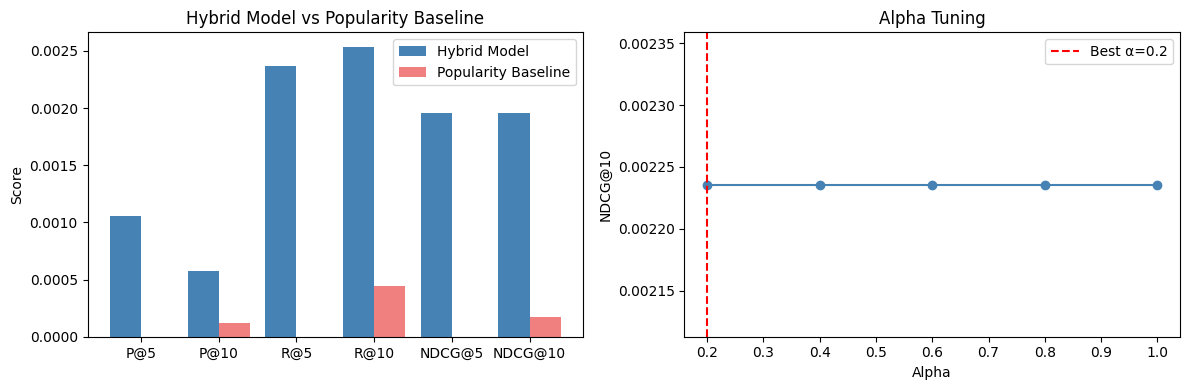

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

metrics    = ["P@5", "P@10", "R@5", "R@10", "NDCG@5", "NDCG@10"]
hybrid_v   = [hybrid_scores[m] for m in metrics]
baseline_v = [baseline_scores[m] for m in metrics]
x = np.arange(len(metrics))

axes[0].bar(x - 0.2, hybrid_v,   0.4, label="Hybrid Model",        color="steelblue")
axes[0].bar(x + 0.2, baseline_v, 0.4, label="Popularity Baseline", color="lightcoral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_title("Hybrid Model vs Popularity Baseline")
axes[0].set_ylabel("Score")
axes[0].legend()

axes[1].plot(alpha_values, alpha_ndcg10, marker="o", color="steelblue")
axes[1].axvline(best_alpha, linestyle="--", color="red", label=f"Best α={best_alpha}")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("NDCG@10")
axes[1].set_title("Alpha Tuning")
axes[1].legend()

plt.tight_layout()
plt.savefig(BASE_DIR + r"\evaluation_plots.png", dpi=150)
plt.show()